In [14]:
import numpy as np
import pandas as pd
import wbgapi as wb
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 20)

In [15]:
PAISES = {
    'AGO': 'Angola',
    'CPV': 'Cabo Verde',
    'GNB': 'Guiné-Bissau',
    'MOZ': 'Moçambique',
    'STP': 'São Tomé e Príncipe',
}

ANO = 2025

# nome da coluna : código do indicador no Banco Mundial
INDICADORES_WDI = {
    'Populacao':          'SP.POP.TOTL',
    'PIB_per_capita_usd': 'NY.GDP.PCAP.CD',
    'Urbanizacao_pct':    'SP.URB.TOTL.IN.ZS',
    'Inflacao_pct':       'FP.CPI.TOTL.ZG',
}

INDICADORES_WGI = {
    'Estab_politica':    'GOV_WGI_PV.EST',
    'Qualidade_regulat': 'GOV_WGI_RQ.EST',
}

# IDH de 2023 (PNUD, HDR 2025) — é o dado mais recente publicado
IDH = {
    'AGO': 0.616,
    'CPV': 0.668,
    'GNB': 0.514,
    'MOZ': 0.493,
    'STP': 0.637,
}

In [16]:
def buscar(indicadores, banco):
    # monta a lista de códigos para pedir ao Banco Mundial
    codigos = []
    for nome in indicadores:
        codigos.append(indicadores[nome])

    tabela = wb.data.DataFrame(codigos, list(PAISES), time=ANO, db=banco)

    # troca o código do indicador pelo nome que escolhemos
    novos_nomes = {}
    for nome in indicadores:
        codigo = indicadores[nome]
        novos_nomes[codigo] = nome

    return tabela.rename(columns=novos_nomes)


wdi = buscar(INDICADORES_WDI, banco=2)
wgi = buscar(INDICADORES_WGI, banco=3)

caracteristicas = pd.concat([wdi, wgi], axis=1)
caracteristicas['IDH'] = pd.Series(IDH)

# deixa os países na ordem da configuração e troca o código (AGO) pelo nome (Angola)
caracteristicas = caracteristicas.reindex(list(PAISES))
caracteristicas.index = caracteristicas.index.map(PAISES)
caracteristicas.index.name = 'Pais'

# mesma ordem de colunas da configuração
colunas = list(INDICADORES_WDI) + list(INDICADORES_WGI) + ['IDH']
caracteristicas = caracteristicas[colunas]

print("Indicadores de", ANO, "(Banco Mundial) e IDH de 2023 (PNUD):")
print()
print(caracteristicas.round(2).to_string())

Indicadores de 2025 (Banco Mundial) e IDH de 2023 (PNUD):

                      Populacao  PIB_per_capita_usd  Urbanizacao_pct  Inflacao_pct  Estab_politica  Qualidade_regulat   IDH
Pais                                                                                                                       
Angola               39040039.0             3129.48            71.46         20.16           -0.44              -0.74  0.62
Cabo Verde             527326.0             5796.47            77.63          2.34            0.86               0.01  0.67
Guiné-Bissau          2249515.0             1123.77            46.65          0.87           -0.53              -1.23  0.51
Moçambique           35631653.0              626.91            37.21          4.37           -1.66              -0.76  0.49
São Tomé e Príncipe    240254.0             4084.40            69.17         11.05            0.55              -0.94  0.64


In [17]:
faltando = caracteristicas.isna().sum().sum()

if faltando == 0:
    print("Todos os indicadores estão completos para os 5 países.")
else:
    print("Valores faltando (True = sem dado):")
    print(caracteristicas.isna().to_string())

Todos os indicadores estão completos para os 5 países.


In [18]:
dados_log = caracteristicas.copy()
dados_log['Populacao'] = np.log10(dados_log['Populacao'])
dados_log['PIB_per_capita_usd'] = np.log10(dados_log['PIB_per_capita_usd'])

print(dados_log.round(2).to_string())

                     Populacao  PIB_per_capita_usd  Urbanizacao_pct  Inflacao_pct  Estab_politica  Qualidade_regulat   IDH
Pais                                                                                                                      
Angola                    7.59                3.50            71.46         20.16           -0.44              -0.74  0.62
Cabo Verde                5.72                3.76            77.63          2.34            0.86               0.01  0.67
Guiné-Bissau              6.35                3.05            46.65          0.87           -0.53              -1.23  0.51
Moçambique                7.55                2.80            37.21          4.37           -1.66              -0.76  0.49
São Tomé e Príncipe       5.38                3.61            69.17         11.05            0.55              -0.94  0.64


In [19]:
VARIAVEIS_SIMILARIDADE = [
    'Populacao',
    'PIB_per_capita_usd',
    'Urbanizacao_pct',
    'Estab_politica',
    'Qualidade_regulat',
    'IDH',
]

print("variáveis na similaridade:", len(VARIAVEIS_SIMILARIDADE))
for variavel in VARIAVEIS_SIMILARIDADE:
    print("   ", variavel)
print()
print("fora: Inflacao_pct (valor do ano, não característica estrutural)")

variáveis na similaridade: 6
    Populacao
    PIB_per_capita_usd
    Urbanizacao_pct
    Estab_politica
    Qualidade_regulat
    IDH

fora: Inflacao_pct (valor do ano, não característica estrutural)


In [20]:
escalador = StandardScaler()
padronizado = escalador.fit_transform(dados_log[VARIAVEIS_SIMILARIDADE])

tabela_padronizada = pd.DataFrame(padronizado,
                                  columns=VARIAVEIS_SIMILARIDADE,
                                  index=caracteristicas.index)

print("Variáveis padronizadas:")
print(tabela_padronizada.round(2).to_string())

Variáveis padronizadas:
                     Populacao  PIB_per_capita_usd  Urbanizacao_pct  Estab_politica  Qualidade_regulat   IDH
Pais                                                                                                        
Angola                    1.17                0.42             0.71           -0.22              -0.03  0.44
Cabo Verde               -0.87                1.16             1.10            1.24               1.81  1.19
Guiné-Bissau             -0.18               -0.81            -0.88           -0.32              -1.22 -1.03
Moçambique                1.13               -1.51            -1.48           -1.59              -0.07 -1.33
São Tomé e Príncipe      -1.25                0.74             0.56            0.89              -0.50  0.74


In [21]:
matriz_distancias = pd.DataFrame(euclidean_distances(padronizado),
                                index=caracteristicas.index,
                                columns=caracteristicas.index)

print("Distância entre os países (menor = mais parecido):")
print()
print(matriz_distancias.round(2).to_string())

Distância entre os países (menor = mais parecido):

Pais                 Angola  Cabo Verde  Guiné-Bissau  Moçambique  São Tomé e Príncipe
Pais                                                                                  
Angola                 0.00        3.31          3.08        3.68                 2.74
Cabo Verde             3.31        0.00          4.98        5.97                 2.50
Guiné-Bissau           3.08        4.98          0.00        2.37                 3.27
Moçambique             3.68        5.97          2.37        0.00                 5.05
São Tomé e Príncipe    2.74        2.50          3.27        5.05                 0.00


In [22]:
for pais in matriz_distancias.index:
    outros = matriz_distancias.loc[pais].drop(pais).sort_values()   # tira o próprio país

    print(pais)
    for posicao in range(len(outros)):
        nome_vizinho = outros.index[posicao]
        distancia = outros.iloc[posicao]
        print("   ", posicao + 1, nome_vizinho.ljust(22), round(distancia, 2))
    print()

Angola
    1 São Tomé e Príncipe    2.74
    2 Guiné-Bissau           3.08
    3 Cabo Verde             3.31
    4 Moçambique             3.68

Cabo Verde
    1 São Tomé e Príncipe    2.5
    2 Angola                 3.31
    3 Guiné-Bissau           4.98
    4 Moçambique             5.97

Guiné-Bissau
    1 Moçambique             2.37
    2 Angola                 3.08
    3 São Tomé e Príncipe    3.27
    4 Cabo Verde             4.98

Moçambique
    1 Guiné-Bissau           2.37
    2 Angola                 3.68
    3 São Tomé e Príncipe    5.05
    4 Cabo Verde             5.97

São Tomé e Príncipe
    1 Cabo Verde             2.5
    2 Angola                 2.74
    3 Guiné-Bissau           3.27
    4 Moçambique             5.05



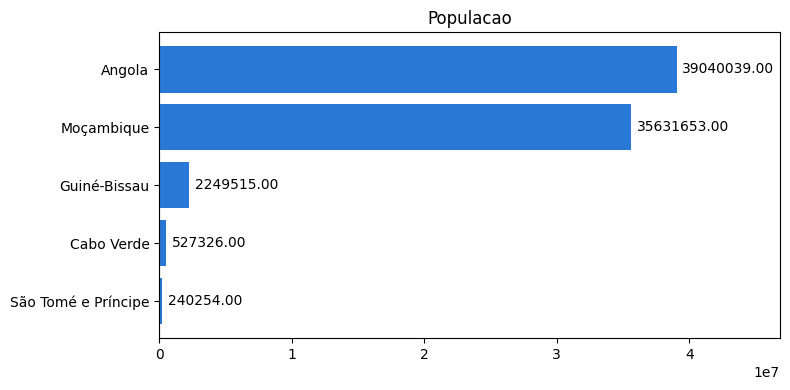

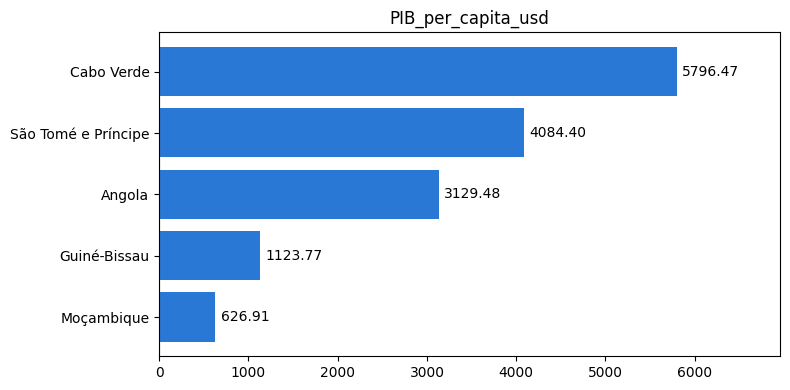

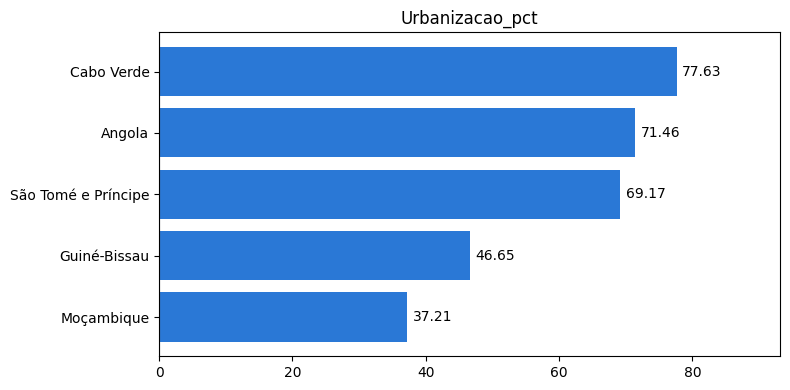

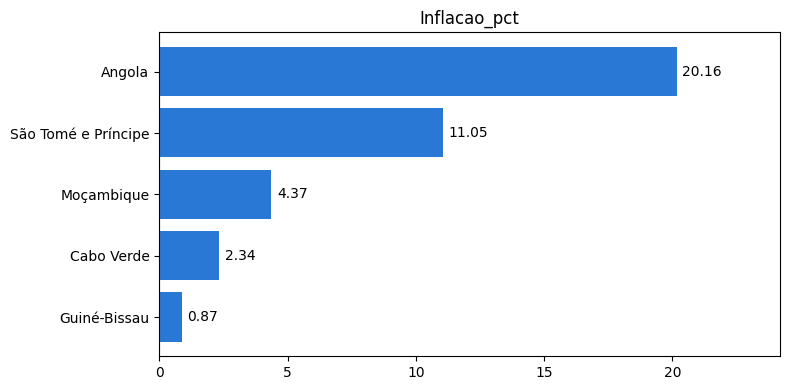

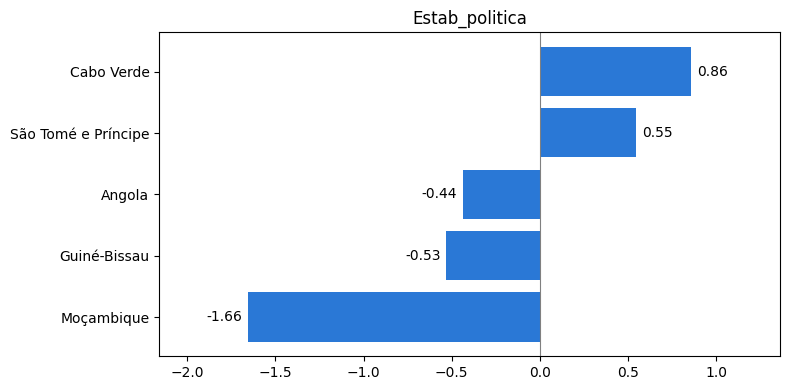

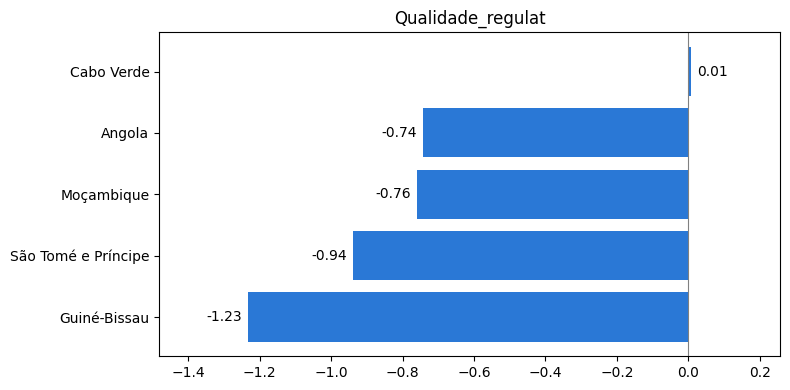

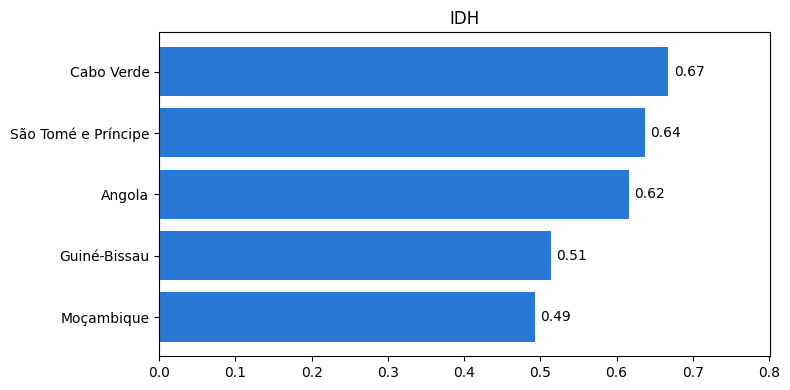

In [23]:
for coluna in colunas:
    valores = caracteristicas[coluna].sort_values()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(valores.index, valores, color='#2a78d6')
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.bar_label(ax.containers[0], fmt='%.2f', padding=4)
    ax.set_title(coluna)
    ax.margins(x=0.2)
    fig.tight_layout()
    fig.savefig("fig_" + coluna.lower() + "_" + str(ANO) + ".png", dpi=300)
    plt.show()

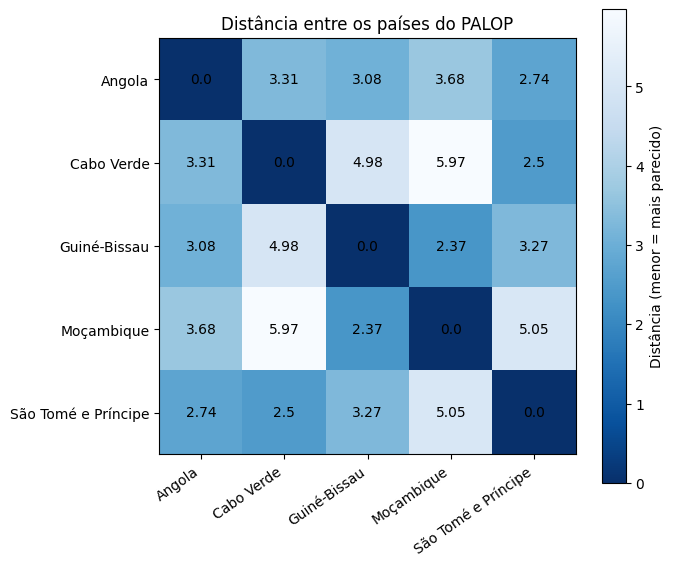

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))
imagem = ax.imshow(matriz_distancias, cmap='Blues_r')   # azul escuro = mais perto

paises = matriz_distancias.index
ax.set_xticks(range(len(paises)), paises, rotation=35, ha='right')
ax.set_yticks(range(len(paises)), paises)

for i in range(len(paises)):
    for j in range(len(paises)):
        ax.text(j, i, round(matriz_distancias.iloc[i, j], 2), ha='center', va='center')

fig.colorbar(imagem, ax=ax, label='Distância (menor = mais parecido)')
ax.set_title('Distância entre os países do PALOP')
fig.tight_layout()
fig.savefig("fig_distancias_palop_" + str(ANO) + ".png", dpi=300)
plt.show()

In [25]:
caracteristicas.to_csv("caracteristicas_paises.csv", encoding='utf-8-sig')
print("caracteristicas_paises.csv:", caracteristicas.shape)

matriz_distancias.to_csv("matriz_distancias.csv", encoding='utf-8-sig')
print("matriz_distancias.csv:    ", matriz_distancias.shape)

caracteristicas_paises.csv: (5, 7)
matriz_distancias.csv:     (5, 5)
